#   EDA: `friends`


**Descripción:** Lista de amigos de cada usuario en Steam. Cada fila contiene el `playerid` y los IDs de todos sus amigos.

| Columna | Tipo | Descripción |
|---|---|---|
| `playerid` | int | ID del jugador |
| `friends` | str (lista serializada) | Lista de `playerids` de sus amigos |


##  Imports y configuración

In [1]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

DARK_BG = '#0e1117'
CARD_BG = '#1a1f2e'
ACCENT1 = '#4f86f7'
ACCENT2 = '#7ee8a2'
ACCENT3 = '#ff6b6b'
ACCENT4 = '#ffd166'
ACCENT5 = '#c77dff'
TEXT    = '#e0e6f0'
MUTED   = '#8892a4'

plt.rcParams.update({
    'figure.facecolor': DARK_BG, 'axes.facecolor': CARD_BG,
    'axes.edgecolor': MUTED,     'axes.labelcolor': TEXT,
    'xtick.color': MUTED,        'ytick.color': MUTED,
    'text.color': TEXT,          'grid.color': '#2d3348',
    'grid.alpha': 0.6,           'font.family': 'DejaVu Sans',
    'font.size': 11,
})

def title_ax(ax, txt, sub=None):
    ax.set_title(txt, fontsize=13, fontweight='bold', color=TEXT, pad=8)
    if sub:
        ax.text(0.5, 1.02, sub, transform=ax.transAxes,
                ha='center', fontsize=9, color=MUTED)

##  Carga - Parser manual para CSV multi-línea

In [2]:

df_private = pd.read_csv('Datos/private_steamids.csv')
private_set = set(df_private['playerid'].tolist())
print(f"IDs privados cargados: {len(private_set):,}")

IDs privados cargados: 227,963


In [3]:
def parse_friends(filepath):
    """Parser para CSV con listas de amigos multi-línea.
    Retorna records (lista parseada OK) y empty_ids (sin amigos).
    """
    records, empty_ids = [], []
    current_pid, current_parts, in_multiline = None, [], False

    with open(filepath, 'r', encoding='utf-8') as f:
        f.readline()  
        for raw_line in f:
            line = raw_line.rstrip('\r\n')
            if not in_multiline:
                comma_idx = line.find(',')
                if comma_idx == -1: continue
                pid_str, rest = line[:comma_idx], line[comma_idx+1:]
                if rest.strip() in ('', '""', '[]'):
                    try: empty_ids.append(int(pid_str))
                    except: pass
                    continue
                if rest.startswith('"'):
                    rest = rest[1:]
                    if rest.endswith('"'):
                        try:
                            friends = [int(f) for f in ast.literal_eval(rest[:-1])]
                            records.append({'playerid': int(pid_str),
                                            'friends': friends, 'n_friends': len(friends)})
                        except: empty_ids.append(int(pid_str))
                    else:
                        current_pid, current_parts, in_multiline = pid_str, [rest], True
                else:
                    try:
                        friends = [int(f) for f in ast.literal_eval(rest)]
                        records.append({'playerid': int(pid_str),
                                        'friends': friends, 'n_friends': len(friends)})
                    except: empty_ids.append(int(pid_str))
            else:
                if line.endswith('"'):
                    current_parts.append(line[:-1])
                    try:
                        friends = [int(f) for f in ast.literal_eval(''.join(current_parts))]
                        records.append({'playerid': int(current_pid),
                                        'friends': friends, 'n_friends': len(friends)})
                    except: empty_ids.append(int(current_pid))
                    current_pid, current_parts, in_multiline = None, [], False
                else:
                    current_parts.append(line)


    if in_multiline and current_pid and current_parts:
        try:
            friends = [int(f) for f in ast.literal_eval(''.join(current_parts) + ']')]
            records.append({'playerid': int(current_pid),
                            'friends': friends, 'n_friends': len(friends), 'truncated': True})
        except: empty_ids.append(int(current_pid))

    return records, empty_ids


FRIENDS_PATH = 'Datos/friends.csv'  
records, empty_ids = parse_friends(FRIENDS_PATH)

total_rows = len(records) + len(empty_ids)
print(f"Total filas en el archivo   : {total_rows:,}")
print(f"Con friends (parseados OK)  : {len(records):,}  ({len(records)/total_rows*100:.1f}%)")
print(f"Sin friends (vacíos)        : {len(empty_ids):,}  ({len(empty_ids)/total_rows*100:.1f}%)")

Total filas en el archivo   : 424,683
Con friends (parseados OK)  : 339,461  (79.9%)
Sin friends (vacíos)        : 85,222  (20.1%)


In [4]:
df = pd.DataFrame([{'playerid': r['playerid'], 'n_friends': r['n_friends'],
                     'is_private': r['playerid'] in private_set} for r in records])

empty_private    = [pid for pid in empty_ids if pid     in private_set]
empty_not_priv   = [pid for pid in empty_ids if pid not in private_set]

friend_sets = {r['playerid']: set(r['friends']) for r in records}
all_nodes   = set(df['playerid'].tolist()) | {fid for r in records for fid in r['friends']}

in_degree = Counter(fid for r in records for fid in r['friends'])

print(f"Usuarios con friends list     : {len(df):,}")
print(f"Nodos únicos en el grafo      : {len(all_nodes):,}")
print(f"Aristas dirigidas totales     : {df['n_friends'].sum():,}")
df.head(3)

Usuarios con friends list     : 339,461
Nodos únicos en el grafo      : 17,531,524
Aristas dirigidas totales     : 30,903,334


,playerid,n_friends,is_private
0,76561198060422271,79,False
1,76561198113439786,104,False
2,76561198149851326,108,False


---
##  Análisis y tratamiento de valores faltantes


| Causa | n | % total | Interpretación |
|---|---|---|---|
| Sin friends + **privado** | 41,160 | 9.7% | Perfil privado — lista de amigos oculta |
| Sin friends + **público** | 44,062 | 10.4% | Usuarios sin amigos o cuentas nuevas/abandonadas |

### Diferencia clave vs `purchased_games`
En `purchased_games`, la mayoría de faltantes provenía de perfiles privados.  
En cambio, en `friends` los faltantes están más equilibrados: aproximadamente 10% privado y 10% público, lo que confirma que tener cero amigos en Steam es un fenómeno real, no solo un efecto de privacidad.


In [5]:
n_total      = total_rows
n_with       = len(records)
n_emp_priv   = len(empty_private)
n_emp_pub    = len(empty_not_priv)

print("Diagnóstico de faltantes:")
print(f"  Con friends list              : {n_with:,}  ({n_with/n_total*100:.1f}%)")
print(f"  Sin friends — privado         : {n_emp_priv:,}  ({n_emp_priv/n_total*100:.1f}%)")
print(f"  Sin friends — público (solos) : {n_emp_pub:,}  ({n_emp_pub/n_total*100:.1f}%)")
print()
print(f"  Privados dentro de con-friends: {df['is_private'].sum():,}  ({df['is_private'].mean()*100:.1f}%)")
print()
print("Duplicados de playerid:", df['playerid'].duplicated().sum())
print("Self-loops (en su propia lista):",
      sum(1 for r in records if r['playerid'] in r['friends']))
print("Amigos duplicados dentro de una misma lista:",
      sum(1 for r in records if len(r['friends']) != len(set(r['friends']))))

Diagnóstico de faltantes:
  Con friends list              : 339,461  (79.9%)
  Sin friends — privado         : 41,160  (9.7%)
  Sin friends — público (solos) : 44,062  (10.4%)

  Privados dentro de con-friends: 186,803  (55.0%)

Duplicados de playerid: 0
Self-loops (en su propia lista): 0
Amigos duplicados dentro de una misma lista: 0


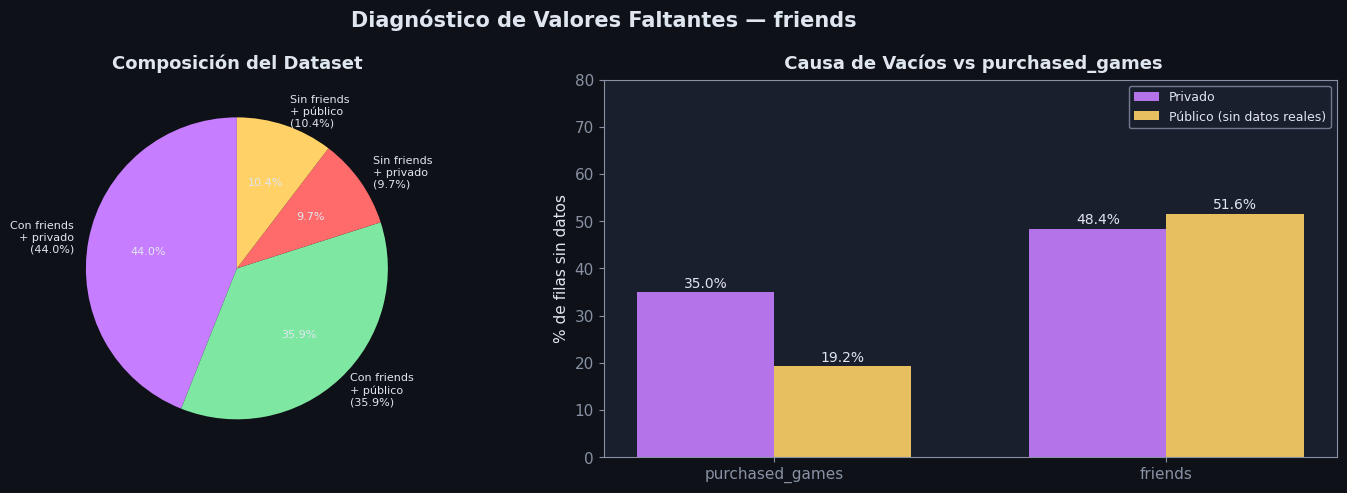

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Diagnóstico de Valores Faltantes — friends', fontsize=15,
             fontweight='bold', color=TEXT)

ax = axes[0]
cats   = ['Con friends\n+ privado', 'Con friends\n+ público',
          'Sin friends\n+ privado', 'Sin friends\n+ público']
vals   = [df['is_private'].sum(), (~df['is_private']).sum(),
          n_emp_priv, n_emp_pub]
colors = [ACCENT5, ACCENT2, ACCENT3, ACCENT4]
ax.pie(vals, labels=[f'{l}\n({v/n_total*100:.1f}%)' for l, v in zip(cats, vals)],
       colors=colors, startangle=90, textprops={'color': TEXT, 'fontsize': 8},
       autopct='%1.1f%%')
title_ax(ax, 'Composición del Dataset')

ax = axes[1]
datasets = ['purchased_games', 'friends']
pct_priv  = [35.0, 48.4]   
pct_pub   = [19.2, 51.6]
x = np.arange(len(datasets))
w = 0.35
ax.bar(x - w/2, pct_priv, width=w, color=ACCENT5, label='Privado', alpha=0.9)
ax.bar(x + w/2, pct_pub,  width=w, color=ACCENT4, label='Público (sin datos reales)', alpha=0.9)
for i, (pv, pu) in enumerate(zip(pct_priv, pct_pub)):
    ax.text(i - w/2, pv + 1, f'{pv:.1f}%', ha='center', fontsize=10, color=TEXT)
    ax.text(i + w/2, pu + 1, f'{pu:.1f}%', ha='center', fontsize=10, color=TEXT)
ax.set_xticks(x); ax.set_xticklabels(datasets)
ax.set_ylabel('% de filas sin datos'); ax.set_ylim(0, 80)
ax.legend(fontsize=9, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
title_ax(ax, 'Causa de Vacíos vs purchased_games')

plt.tight_layout()
plt.show()

In [7]:
rows_all = []
for r in records:
    rows_all.append({'playerid': r['playerid'], 'n_friends': r['n_friends'],
                     'has_friends': True,
                     'is_private': r['playerid'] in private_set,
                     'reason': 'ok_private' if r['playerid'] in private_set else 'ok_public'})
for pid in empty_private:
    rows_all.append({'playerid': pid, 'n_friends': 0, 'has_friends': False,
                     'is_private': True, 'reason': 'private_no_data'})
for pid in empty_not_priv:
    rows_all.append({'playerid': pid, 'n_friends': 0, 'has_friends': False,
                     'is_private': False, 'reason': 'no_friends'})

df_all = pd.DataFrame(rows_all)
print("Distribución de 'reason':")
print(df_all['reason'].value_counts())
print()
print("→ Para ML: usar df (has_friends=True) con flag is_private.")
print("→ Usuarios 'no_friends' pueden recibir n_friends=0 imputado — son jugadores solitarios.")

Distribución de 'reason':
reason
ok_private         186803
ok_public          152658
no_friends          44062
private_no_data     41160
Name: count, dtype: int64

→ Para ML: usar df (has_friends=True) con flag is_private.
→ Usuarios 'no_friends' pueden recibir n_friends=0 imputado — son jugadores solitarios.


---
##  Distribución de Amigos por Usuario

- La distribución es **moderadamente sesgada a la derecha**: mediana 62 amigos, media 91. Mucho menos extrema que `lib_size`, lo que sugiere que las redes sociales en Steam tienen un techo más natural.
- El límite oficial de Steam para cuentas gratuitas es 250 amigos. En el dataset, 19,810 usuarios (5.8%) superan ese límite, lo que indica cuentas con Steam Level elevado (el límite puede aumentar hasta 2,000).
- 617 usuarios tienen más de 1,000 amigos, y 16 usuarios alcanzan el máximo posible de 2,000 amigos.
- El umbral IQR (>262 amigos) identifica 16,988 usuarios (5.0%) como outliers, una proporción moderada que refleja jugadores con redes sociales especialmente grandes.



In [8]:
print("Estadísticas de n_friends:")
print(df['n_friends'].describe(percentiles=[.1, .25, .5, .75, .90, .95, .99]))
print()

Q1  = df['n_friends'].quantile(0.25)
Q3  = df['n_friends'].quantile(0.75)
IQR = Q3 - Q1
upper_iqr = Q3 + 1.5 * IQR
p99       = df['n_friends'].quantile(0.99)

STEAM_FREE_LIMIT    = 250
STEAM_PREMIUM_LIMIT = 2000

print(f"Q1={Q1:.0f}  Q3={Q3:.0f}  IQR={IQR:.0f}")
print(f"Umbral IQR (Q3 + 1.5×IQR)         : {upper_iqr:.0f} amigos")
print(f"Percentil 99                       : {p99:.0f} amigos")
print()
print(f"Límite Steam free (250)            : {(df['n_friends'] == 250).sum()} en el tope exacto")
print(f"Usuarios sobre límite free (>250)  : {(df['n_friends'] > 250).sum():,}  ({(df['n_friends'] > 250).mean()*100:.1f}%)")
print(f"Usuarios sobre 1000 amigos         : {(df['n_friends'] > 1000).sum():,}")
print(f"Usuarios con máximo premium (2000) : {(df['n_friends'] == 2000).sum()}")
print(f"Outliers IQR (>{upper_iqr:.0f})            : {(df['n_friends'] > upper_iqr).sum():,}  ({(df['n_friends'] > upper_iqr).mean()*100:.1f}%)")

Estadísticas de n_friends:
count    339461.000000
mean         91.036478
std         109.228394
min           1.000000
10%          10.000000
25%          27.000000
50%          62.000000
75%         121.000000
90%         205.000000
95%         263.000000
99%         427.000000
max        2000.000000
Name: n_friends, dtype: float64

Q1=27  Q3=121  IQR=94
Umbral IQR (Q3 + 1.5×IQR)         : 262 amigos
Percentil 99                       : 427 amigos

Límite Steam free (250)            : 240 en el tope exacto
Usuarios sobre límite free (>250)  : 19,810  (5.8%)
Usuarios sobre 1000 amigos         : 617
Usuarios con máximo premium (2000) : 16
Outliers IQR (>262)            : 16,988  (5.0%)


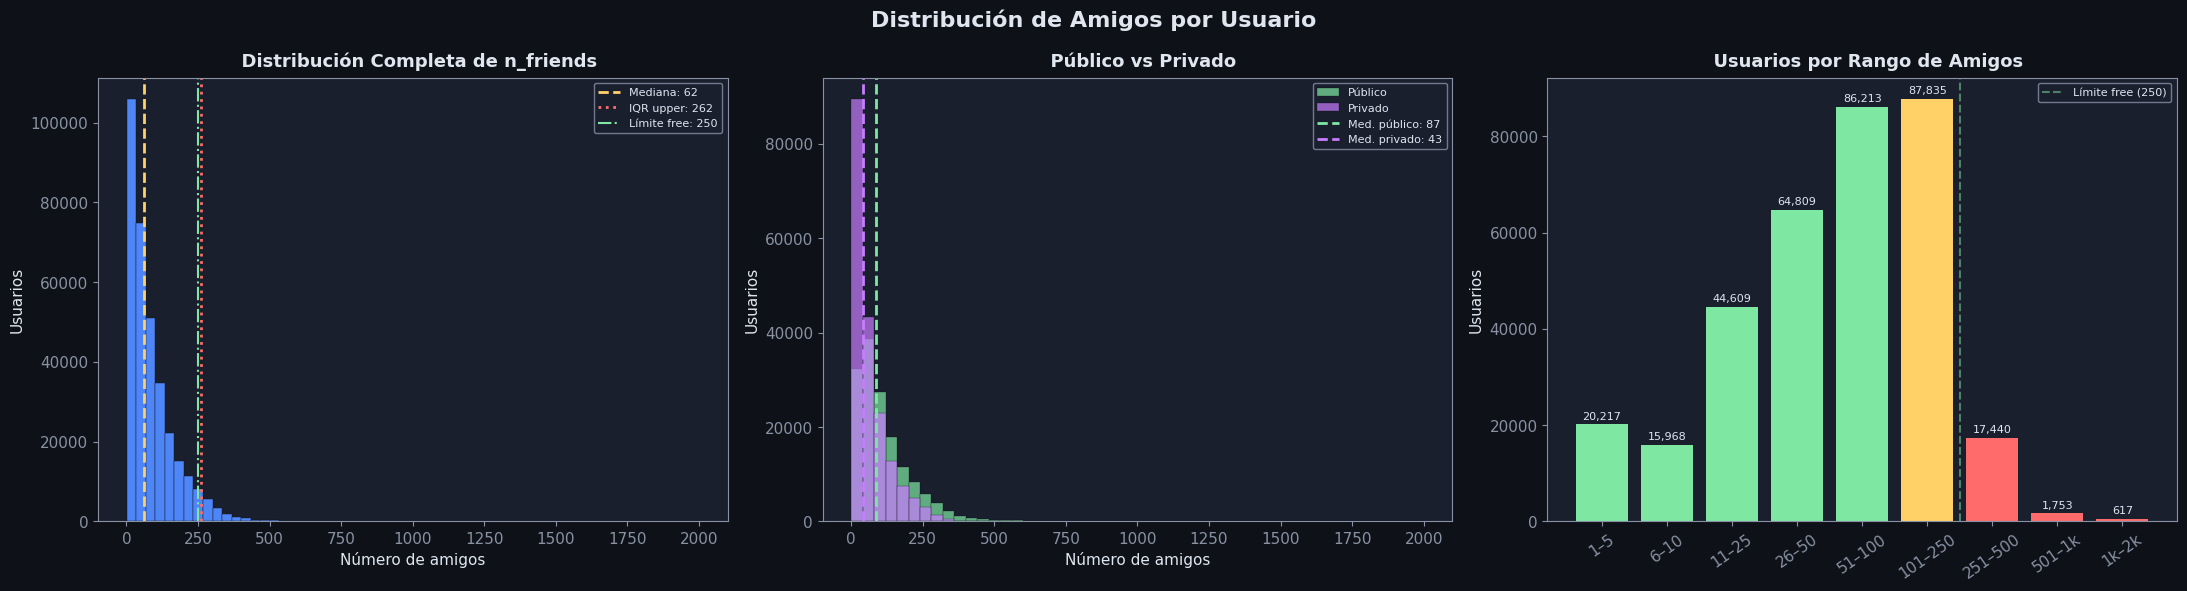

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Distribución de Amigos por Usuario', fontsize=16, fontweight='bold', color=TEXT)

ax = axes[0]
ax.hist(df['n_friends'], bins=60, color=ACCENT1, edgecolor=DARK_BG, linewidth=0.3)
ax.axvline(df['n_friends'].median(), color=ACCENT4, linewidth=2, linestyle='--',
           label=f'Mediana: {df["n_friends"].median():.0f}')
ax.axvline(upper_iqr, color=ACCENT3, linewidth=2, linestyle=':',
           label=f'IQR upper: {upper_iqr:.0f}')
ax.axvline(STEAM_FREE_LIMIT, color=ACCENT2, linewidth=1.5, linestyle='-.',
           label=f'Límite free: {STEAM_FREE_LIMIT}')
ax.legend(fontsize=8, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.set_xlabel('Número de amigos'); ax.set_ylabel('Usuarios')
title_ax(ax, '  Distribución Completa de n_friends')

ax = axes[1]
ax.hist(df[df['is_private']==False]['n_friends'], bins=50, color=ACCENT2,
        alpha=0.7, edgecolor=DARK_BG, linewidth=0.3, label='Público')
ax.hist(df[df['is_private']==True]['n_friends'],  bins=50, color=ACCENT5,
        alpha=0.7, edgecolor=DARK_BG, linewidth=0.3, label='Privado')
ax.axvline(df[df['is_private']==False]['n_friends'].median(), color=ACCENT2,
           linewidth=2, linestyle='--',
           label=f'Med. público: {df[df["is_private"]==False]["n_friends"].median():.0f}')
ax.axvline(df[df['is_private']==True]['n_friends'].median(), color=ACCENT5,
           linewidth=2, linestyle='--',
           label=f'Med. privado: {df[df["is_private"]==True]["n_friends"].median():.0f}')
ax.legend(fontsize=8, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.set_xlabel('Número de amigos'); ax.set_ylabel('Usuarios')
title_ax(ax, '  Público vs Privado')

ax = axes[2]
bins_r   = [0, 5, 10, 25, 50, 100, 250, 500, 1000, 2001]
labels_r = ['1–5','6–10','11–25','26–50','51–100','101–250','251–500','501–1k','1k–2k']
df['friend_bucket'] = pd.cut(df['n_friends'], bins=bins_r, labels=labels_r)
bc = df['friend_bucket'].value_counts().sort_index()
colors_r = [ACCENT2 if i < 5 else ACCENT4 if i < 6 else ACCENT3 for i in range(len(bc))]
ax.bar(bc.index.astype(str), bc.values, color=colors_r)
for i, v in enumerate(bc.values):
    if v > 0:
        ax.text(i, v + len(df)*0.003, f'{v:,}', ha='center', fontsize=8, color=TEXT)
ax.axvline(5.5, color=ACCENT2, linewidth=1.5, linestyle='--', alpha=0.5,
           label='Límite free (250)')
ax.tick_params(axis='x', rotation=35); ax.set_ylabel('Usuarios')
ax.legend(fontsize=8, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
title_ax(ax, '  Usuarios por Rango de Amigos')

plt.tight_layout()
plt.show()

---
##  Análisis de Grafo 


- La red de amigos forma un grafo dirigido masivo con 30.9M aristas. Sin embargo, solo 1.48M aristas (4.8%) conectan usuarios que aparecen como nodos en el dataset; el resto apunta a jugadores fuera de la muestra.

- Se detectan 1,473,180 aristas recíprocas, equivalentes a 736,590 pares mutuos. Esto representa aproximadamente 4.77% de todas las aristas, lo que refleja reciprocidad limitada dentro del subconjunto observable.

- El in-degree (cuántas veces un jugador aparece en listas de amigos) tiene mediana 1 y media 1.76, lo que indica que la mayoría de nodos son periféricos dentro del grafo.

- Sin embargo, existen hubs sociales con in-degree muy alto (máximo 1,123), que probablemente corresponden a usuarios muy activos, comunidades o figuras públicas dentro de Steam.

- El grafo contienen 17.5M nodos únicos con al menos una referencia, lo que muestra que el dataset captura solo una pequeña fracción del grafo completo de Steam, pero suficiente para observar su estructura de red.


In [10]:
players_in_sample = set(df['playerid'].tolist())

total_directed = df['n_friends'].sum()
mutual_pairs   = set()
reciprocal_edges = 0
for pid, fs in friend_sets.items():
    for fid in fs:
        if fid in friend_sets and pid in friend_sets[fid]:
            reciprocal_edges += 1
            mutual_pairs.add(tuple(sorted([pid, fid])))

edges_within = sum(1 for pid, fs in friend_sets.items()
                   for fid in fs if fid in players_in_sample)

print(f"Aristas dirigidas totales          : {total_directed:,}")
print(f"Aristas entre nodos en la muestra  : {edges_within:,}  ({edges_within/total_directed*100:.1f}%)")
print(f"Aristas recíprocas (A→B y B→A)     : {reciprocal_edges:,}  ({reciprocal_edges/total_directed*100:.2f}%)")
print(f"Pares mutuos únicos                : {len(mutual_pairs):,}")
print()

in_deg_vals = list(in_degree.values())
in_deg_s    = sorted(in_deg_vals)
m           = len(in_deg_s)
print(f"Nodos únicos con in-degree > 0     : {len(in_degree):,}")
print(f"In-degree — median={in_deg_s[m//2]}, mean={sum(in_deg_vals)/m:.2f}, max={max(in_deg_vals)}")
print()
print("Top 10 jugadores más referenciados (mayor in-degree):")
display(pd.DataFrame(in_degree.most_common(10), columns=['playerid', 'in_degree']))

Aristas dirigidas totales          : 30,903,334
Aristas entre nodos en la muestra  : 1,478,645  (4.8%)
Aristas recíprocas (A→B y B→A)     : 1,473,180  (4.77%)
Pares mutuos únicos                : 736,590

Nodos únicos con in-degree > 0     : 17,527,499
In-degree — median=1, mean=1.76, max=1123

Top 10 jugadores más referenciados (mayor in-degree):


,playerid,in_degree
0,76561198146253210,1123
1,76561198842603734,994
2,76561198083134207,928
3,76561197993777514,796
4,76561198117967228,693
5,76561198042359209,635
6,76561197970417960,589
7,76561198194795287,536
8,76561198045324497,511
9,76561198036629241,477


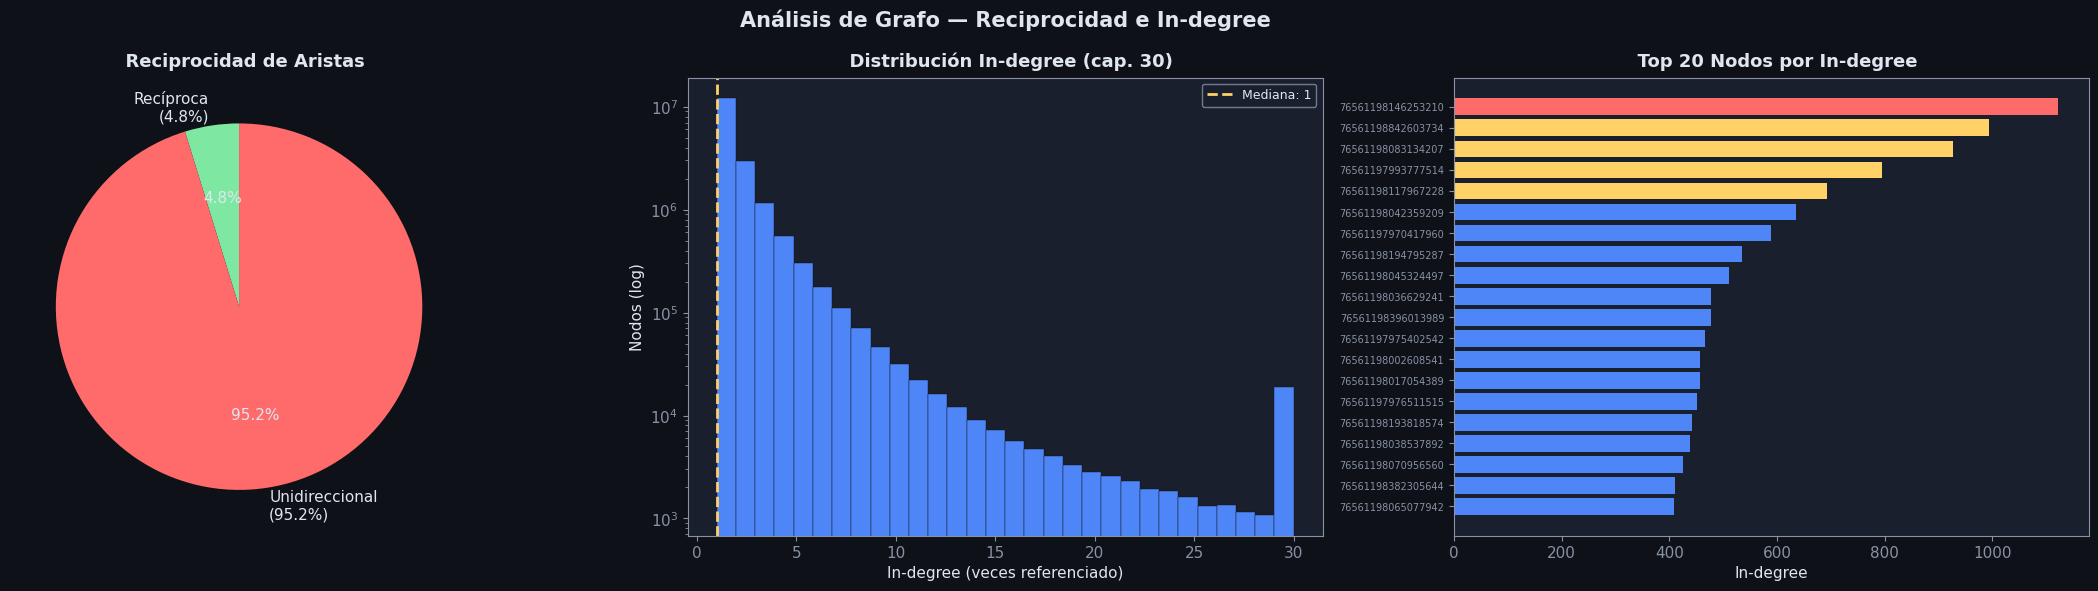

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Análisis de Grafo — Reciprocidad e In-degree', fontsize=15,
             fontweight='bold', color=TEXT)

ax = axes[0]
ax.pie([reciprocal_edges, total_directed - reciprocal_edges],
       labels=[f'Recíproca\n({reciprocal_edges/total_directed*100:.1f}%)',
               f'Unidireccional\n({(total_directed-reciprocal_edges)/total_directed*100:.1f}%)'],
       colors=[ACCENT2, ACCENT3], startangle=90,
       textprops={'color': TEXT}, autopct='%1.1f%%')
title_ax(ax, '  Reciprocidad de Aristas')

ax = axes[1]
in_deg_series = pd.Series(in_deg_vals)
ax.hist(in_deg_series.clip(upper=30), bins=30, color=ACCENT1,
        edgecolor=DARK_BG, linewidth=0.3, log=True)
ax.axvline(in_deg_series.median(), color=ACCENT4, linewidth=2, linestyle='--',
           label=f'Mediana: {in_deg_series.median():.0f}')
ax.legend(fontsize=9, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.set_xlabel('In-degree (veces referenciado)'); ax.set_ylabel('Nodos (log)')
title_ax(ax, '  Distribución In-degree (cap. 30)')

ax = axes[2]
top20_in = pd.DataFrame(in_degree.most_common(20), columns=['playerid', 'in_degree'])
colors_in = [ACCENT3 if v == top20_in['in_degree'].max() else ACCENT4
             if v > top20_in['in_degree'].quantile(0.75) else ACCENT1
             for v in top20_in['in_degree'].values]
ax.barh(top20_in['playerid'].astype(str)[::-1],
        top20_in['in_degree'].values[::-1], color=colors_in[::-1])
ax.set_xlabel('In-degree')
ax.tick_params(axis='y', labelsize=7)
title_ax(ax, '  Top 20 Nodos por In-degree')

plt.tight_layout()
plt.show()

---
##  Outliers: Usuarios con Demasiados Amigos


- Steam tiene dos límites según el nivel de cuenta:
  - **250 amigos** — cuentas gratuitas (Steam Level 0)
  - **Hasta 2,000** — cuentas con Steam Level elevado (cada 10 niveles suman 5 slots)
- Los usuarios sobre 250 amigos son plausibles si tienen cuentas premium activas. Sin embargo, el análisis debe tener en cuenta que `n_friends` puede no reflejar amigos activos — muchas de estas relaciones pueden ser inactivas.


In [ ]:
def social_tier(n, upper=upper_iqr):
    if n == 0:      return 'solitario'
    elif n <= 25:   return 'casual'
    elif n <= 250:  return 'social'
    else:           return 'hub'

df['social_tier']     = df['n_friends'].map(social_tier)
df['n_friends_log']   = np.log1p(df['n_friends'])
df['over_free_limit'] = df['n_friends'] > STEAM_FREE_LIMIT

n_solitarios = n_emp_pub  

tier_counts = df['social_tier'].value_counts()
print("social_tier (usuarios con friends list):")
for t, n in tier_counts.items():
    print(f"  {t:<12}: {n:,}  ({n/len(df)*100:.1f}%)")
print(f"  {'solitario':<12}: {n_solitarios:,}  (usuarios públicos sin amigos — df_all)")
print()
print(f"Usuarios sobre límite free (>250): {df['over_free_limit'].sum():,}  ({df['over_free_limit'].mean()*100:.1f}%)")
print()
print("n_friends_log stats:")
print(df['n_friends_log'].describe().round(3))

social_tier (usuarios con friends list):
  social      : 238,857  (70.4%)
  casual      : 80,794  (23.8%)
  hub         : 19,810  (5.8%)
  solitario   : 44,062  (usuarios públicos sin amigos — df_all)

Usuarios sobre límite free (>250): 19,810  (5.8%)

n_friends_log stats:
count    339461.000
mean          3.982
std           1.155
min           0.693
25%           3.332
50%           4.143
75%           4.804
max           7.601
Name: n_friends_log, dtype: float64


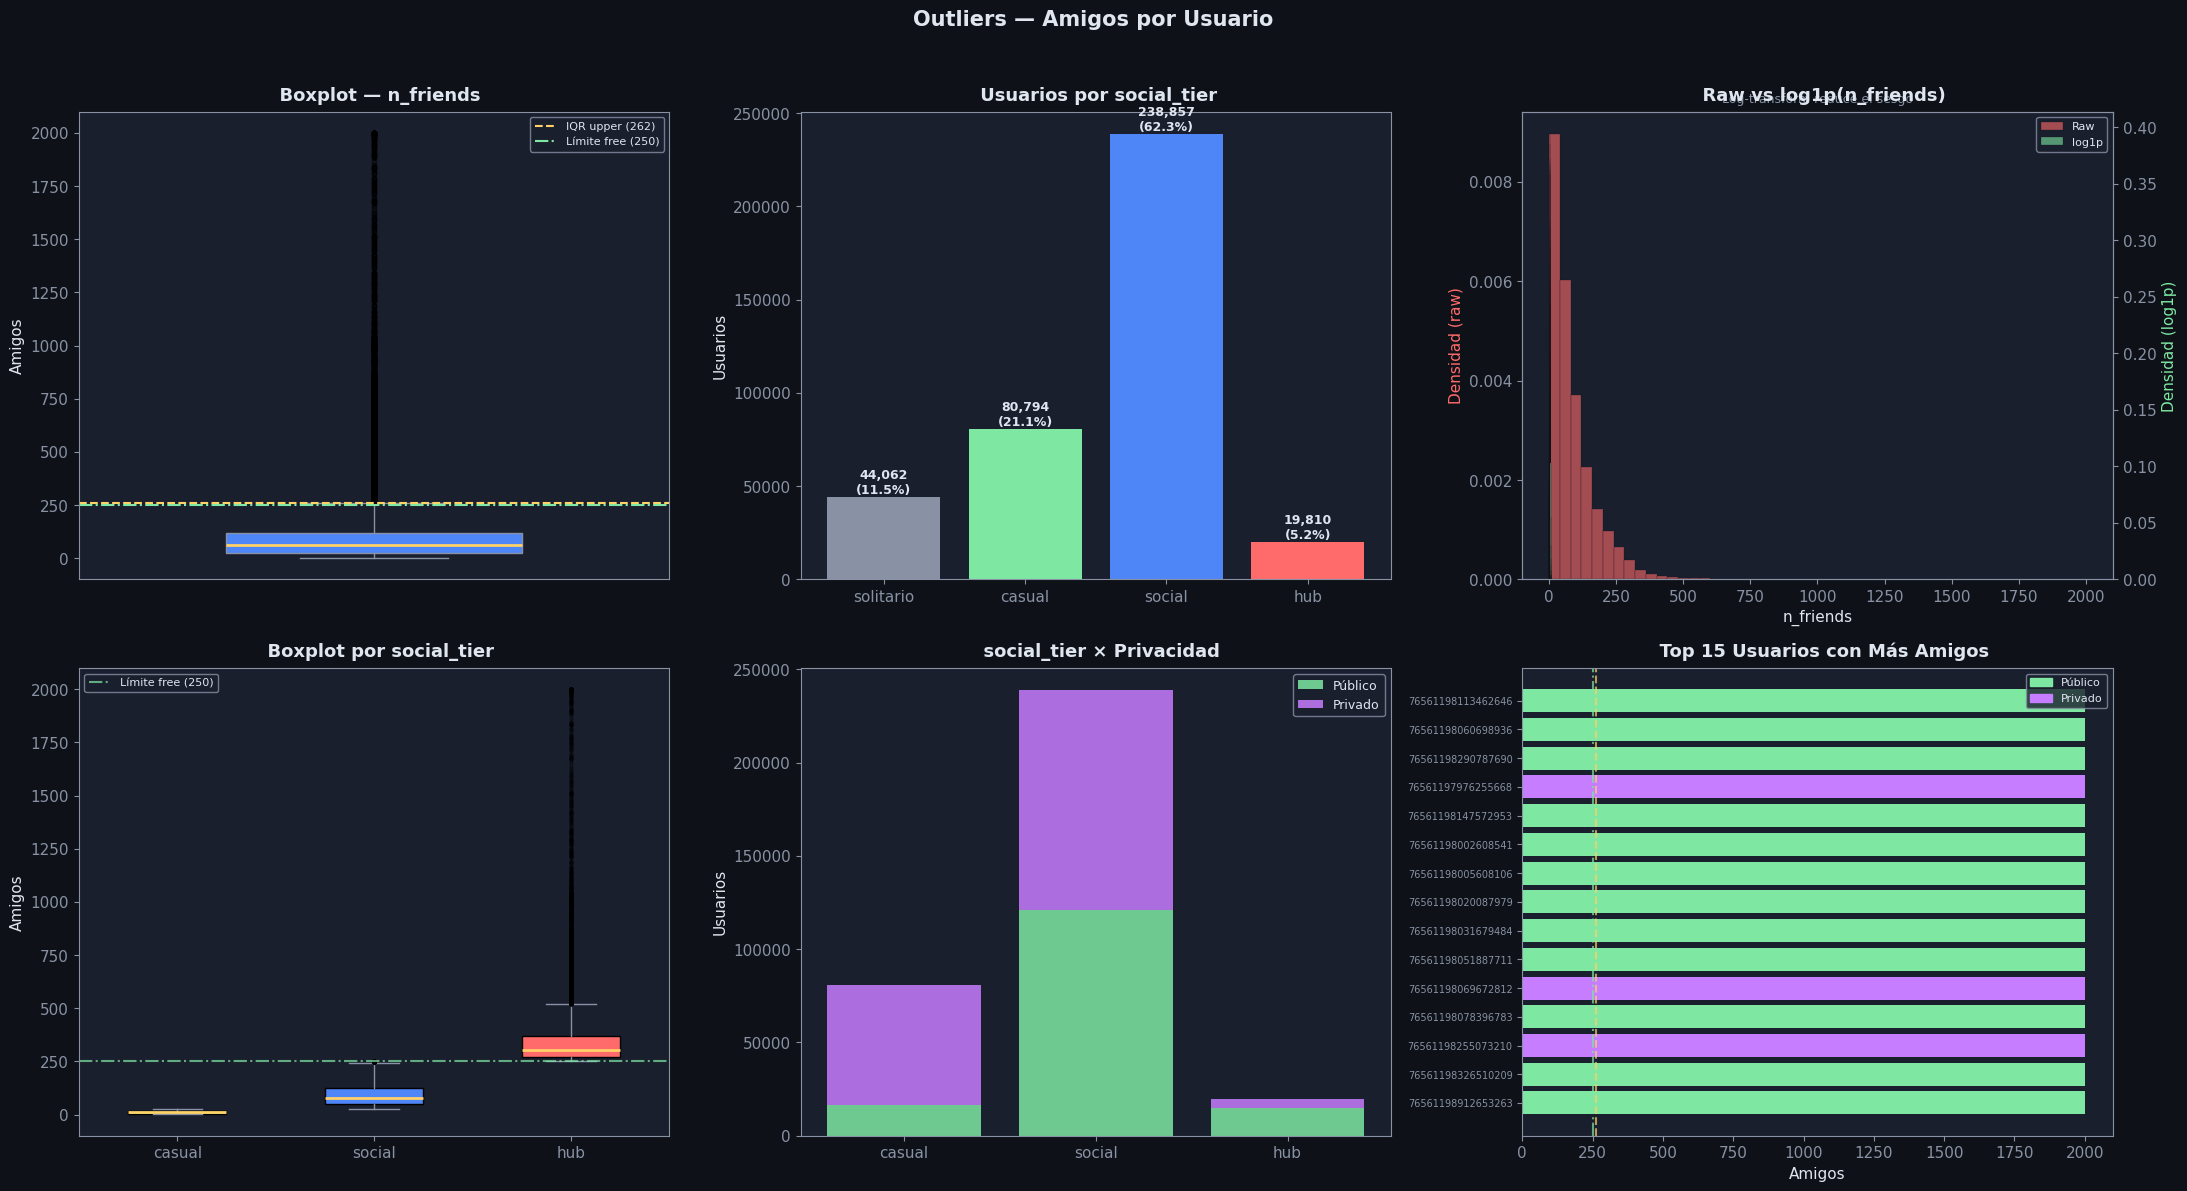

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Outliers — Amigos por Usuario', fontsize=15,
             fontweight='bold', color=TEXT, y=0.99)

tier_order  = ['casual', 'social', 'hub']
tier_colors = [ACCENT2, ACCENT1, ACCENT3]

ax = axes[0, 0]
bp = ax.boxplot(df['n_friends'].values, vert=True, patch_artist=True, widths=0.5,
                boxprops=dict(facecolor=ACCENT1, color=MUTED),
                medianprops=dict(color=ACCENT4, linewidth=2),
                whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED),
                flierprops=dict(marker='o', color=ACCENT3, alpha=0.3, markersize=3))
ax.axhline(upper_iqr, color=ACCENT4, linewidth=1.5, linestyle='--',
           label=f'IQR upper ({upper_iqr:.0f})')
ax.axhline(STEAM_FREE_LIMIT, color=ACCENT2, linewidth=1.5, linestyle='-.',
           label=f'Límite free ({STEAM_FREE_LIMIT})')
ax.legend(fontsize=8, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.set_ylabel('Amigos'); ax.set_xticks([])
title_ax(ax, '  Boxplot — n_friends')

ax = axes[0, 1]
all_tiers   = ['solitario'] + tier_order
all_colors  = [MUTED, ACCENT2, ACCENT1, ACCENT3]
all_vals    = [n_solitarios] + [tier_counts.get(t, 0) for t in tier_order]
bars_t = ax.bar(all_tiers, all_vals, color=all_colors)
for bar, val in zip(bars_t, all_vals):
    tot = len(df) + n_solitarios
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + tot*0.005,
            f'{val:,}\n({val/tot*100:.1f}%)', ha='center', fontsize=9,
            color=TEXT, fontweight='bold')
ax.set_ylabel('Usuarios')
title_ax(ax, ' Usuarios por social_tier')

ax = axes[0, 2]
ax.hist(df['n_friends'],     bins=50, color=ACCENT3, alpha=0.6,
        edgecolor=DARK_BG, linewidth=0.3, label='Raw', density=True)
ax2 = ax.twinx()
ax2.hist(df['n_friends_log'], bins=50, color=ACCENT2, alpha=0.6,
         edgecolor=DARK_BG, linewidth=0.3, label='log1p', density=True)
ax2.tick_params(colors=MUTED)
ax.set_xlabel('n_friends')
ax.set_ylabel('Densidad (raw)', color=ACCENT3)
ax2.set_ylabel('Densidad (log1p)', color=ACCENT2)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8,
          facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
title_ax(ax, '  Raw vs log1p(n_friends)', 'Log-transform reduce el sesgo')

ax = axes[1, 0]
data_box = [df[df['social_tier']==t]['n_friends'].values for t in tier_order]
bp2 = ax.boxplot(data_box, vert=True, patch_artist=True, widths=0.5,
                 medianprops=dict(color=ACCENT4, linewidth=2),
                 whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED),
                 flierprops=dict(marker='o', alpha=0.2, markersize=2))
for patch, color in zip(bp2['boxes'], tier_colors):
    patch.set_facecolor(color)
ax.set_xticklabels(tier_order)
ax.axhline(STEAM_FREE_LIMIT, color=ACCENT2, linewidth=1.5, linestyle='-.',
           label=f'Límite free ({STEAM_FREE_LIMIT})', alpha=0.7)
ax.legend(fontsize=8, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.set_ylabel('Amigos')
title_ax(ax, '  Boxplot por social_tier')

ax = axes[1, 1]
pub_t  = [df[(df['is_private']==False) & (df['social_tier']==t)].shape[0] for t in tier_order]
priv_t = [df[(df['is_private']==True ) & (df['social_tier']==t)].shape[0] for t in tier_order]
x = np.arange(len(tier_order))
ax.bar(x, pub_t,  color=ACCENT2, label='Público',  alpha=0.85)
ax.bar(x, priv_t, color=ACCENT5, label='Privado',  alpha=0.85, bottom=pub_t)
ax.set_xticks(x); ax.set_xticklabels(tier_order)
ax.set_ylabel('Usuarios')
ax.legend(fontsize=9, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
title_ax(ax, '  social_tier × Privacidad')

ax = axes[1, 2]
top15 = df.nlargest(15, 'n_friends')
colors_t15 = [ACCENT5 if priv else ACCENT2 for priv in top15['is_private'].values]
ax.barh(top15['playerid'].astype(str)[::-1], top15['n_friends'].values[::-1],
        color=colors_t15[::-1])
ax.axvline(STEAM_FREE_LIMIT, color=ACCENT2, linewidth=1.5, linestyle='-.',
           alpha=0.7, label=f'Límite free ({STEAM_FREE_LIMIT})')
ax.axvline(upper_iqr, color=ACCENT4, linewidth=1.5, linestyle='--',
           alpha=0.7, label=f'IQR upper ({upper_iqr:.0f})')
ax.legend(fontsize=8, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.tick_params(axis='y', labelsize=7); ax.set_xlabel('Amigos')
legend_els = [mpatches.Patch(color=ACCENT2, label='Público'),
              mpatches.Patch(color=ACCENT5, label='Privado')]
ax.legend(handles=legend_els, fontsize=8, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
title_ax(ax, '  Top 15 Usuarios con Más Amigos')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

---
## Exportar dataset limpio



**Archivo generado:**
- `friends_clean.csv`  una fila por usuario (incluyendo los sin amigos): `playerid`, `n_friends`, `n_friends_log`, `social_tier`, `is_private`, `has_friends`


In [ ]:
cols_friends = ['playerid','n_friends','n_friends_log','social_tier','is_private','has_friends']

import numpy as np
df_all['n_friends_log'] = np.log1p(df_all['n_friends'].fillna(0))
df_all['social_tier']   = df_all['n_friends'].fillna(0).map(
    lambda n: 'solitario' if n == 0 else 'casual' if n <= 25 else 'social' if n <= 250 else 'hub'
)

df_all[cols_friends].to_csv('Datos/friends_clean.csv', index=False)

print(f'friends_clean.csv : {len(df_all):,} usuarios, {len(cols_friends)} columnas')
print(f'  Con friends list     : {df_all["has_friends"].sum():,}')
print(f'  Sin friends (solos)  : {(~df_all["has_friends"]).sum():,}')
df_all[cols_friends].head(3)


friends_clean.csv : 424,683 usuarios, 6 columnas
  Con friends list     : 339,461
  Sin friends (solos)  : 85,222


,playerid,n_friends,n_friends_log,social_tier,is_private,has_friends
0,76561198060422271,79,4.382027,social,False,True
1,76561198113439786,104,4.653960,social,False,True
2,76561198149851326,108,4.691348,social,False,True


---
##  Conclusiones


### Próximos pasos
- **Feature para regresión:** usar `n_friends_log` y `social_tier` como features del usuario — proxy de engagement social.
- **Cruzar con `history`:** ¿los usuarios con más amigos desbloquean más logros? ¿Correlación `n_friends` ↔ `n_logros_par`?
- **Cruzar con `players`:** ¿hay correlación `country` ↔ `n_friends`? ¿Ciertos países tienden más a la red social en Steam?
